# Download and Plot NOAA/NSIDC Climate Data Record of Passive Microwave Sea Ice Concentration, Version 5

Data is sourced from the NSIDC Climate Data Record: https://nsidc.org/data/g02202/versions/5#anchor-data-access-tools<br>

Ancillary data files are found at: https://noaadata.apps.nsidc.org/NOAA/G02202_V5/ancillary/

### 1. To download a single file, run:

``
wget -nd --no-check-certificate --reject "index.html*" -np -e robots=off https://noaadata.apps.nsidc.org/NOAA/G02202_V5/north/daily/2016/sic_psn25_20161025_F17_v05r00.nc 
``

### 2. If you want to download many files, create a txt file with a list of the files you want

Here is an example shell script (saved as 'make_sic_file_list.sh') to generate the text file 'sic_file_list.txt' with a list of netcdf files for Sept-Dec between 2014-2022:<br>
```
#!/bin/bash

# Output file for the list of URLs
LIST="sic_file_list.txt"
> "$LIST"

# Loop through years and months
for YEAR in {2014..2024}; do
  for MONTH in 09 10 11 12; do
    # Generate days for this month
    for DAY in $(seq -w 1 31); do
      # Use GNU date to validate the date
      if date -d "$YEAR-$MONTH-$DAY" >/dev/null 2>&1; then
        DATE="${YEAR}${MONTH}${DAY}"
        FILE="sic_psn25_${DATE}_F17_v05r00.nc"
        echo "https://noaadata.apps.nsidc.org/NOAA/G02202_V5/north/daily/${YEAR}/${FILE}" >> "$LIST"
      fi
    done
  done
done

```

To run the shell script, go to your console and run:<br>
`sh make_sic_file_list.sh`

Now you have a text file with the list of files you want (named 'sic_file_list.txt'). In your console, navigate to the directory where the text file is located and run: <br>
`wget -nc -nd --no-check-certificate --reject "index.html*" -np -e robots=off -i sic_file_list.txt -P /path/to/your/download_dir/`<br>
**YOU WILL NEED TO CHANGE THE DIRECTORY /path/to/your/download_dir/ TO WHERE YOU WANT THE FILES SAVED**

### 3. Open and plot one netCDF file

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os

Open the file

In [4]:
# open netCDF file
ds = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20161026_F17_v05r00.nc')

Convert North Polar Stereographic to Lat/Lon Coordinates

In [5]:
# Extract x and y
x = ds['x'].values
y = ds['y'].values
X, Y = np.meshgrid(x, y)

# Set up projection: NSIDC Polar Stereographic North (EPSG:3411 equivalent)
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Transform x/y to lon/lat
lon2d, lat2d = transformer.transform(X, Y)

# Add lat/lon as DataArrays to the dataset
ds = ds.assign_coords({
    "lat": (("y", "x"), lat2d),
    "lon": (("y", "x"), lon2d)
})

# Confirm structure
ds

<xarray.Dataset> Size: 4MB
Dimensions:                               (time: 1, y: 448, x: 304)
Coordinates:
  * x                                     (x) float64 2kB -3.838e+06 ... 3.73...
  * y                                     (y) float64 4kB 5.838e+06 ... -5.33...
  * time                                  (time) datetime64[ns] 8B 2016-10-26
    lat                                   (y, x) float64 1MB 31.1 31.2 ... 34.47
    lon                                   (y, x) float64 1MB 168.3 ... -9.999
Data variables:
    crs                                   int32 4B ...
    cdr_seaice_conc_interp_spatial_flag   (time, y, x) uint8 136kB ...
    cdr_seaice_conc_qa_flag               (time, y, x) uint8 136kB ...
    cdr_seaice_conc_interp_temporal_flag  (time, y, x) uint8 136kB ...
    cdr_seaice_conc                       (time, y, x) float64 1MB ...
    cdr_seaice_conc_stdev                 (time, y, x) float32 545kB ...
Attributes: (12/46)
    Conventions:               CF-1.11, ACDD-1.3
    date_created:              2024-11-12T05:38:14Z
    time_coverage_start:       2016-10-26T00:00:00Z
    time_coverage_end:         2016-10-26T23:59:59Z
    time_coverage_duration:    P1D
    time_coverage_resolution:  P1D
    ...                        ...
    geospatial_lat_min:        30.980564
    geospatial_lat_max:        90.0
    geospatial_lon_min:        -180.0
    geospatial_lon_max:        180.0
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east

Plot

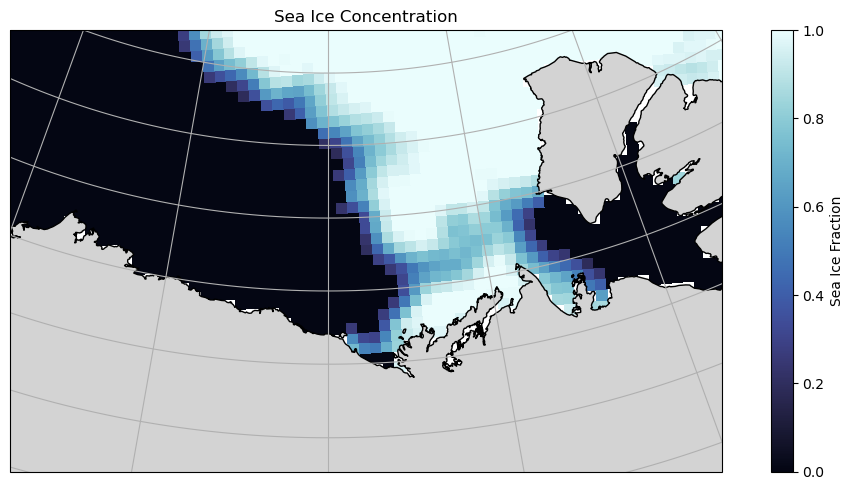

In [8]:
# Extract and normalize sea ice concentration
sic = ds['cdr_seaice_conc'].squeeze()
if sic.max() > 1.5:
    sic = sic / 100.0

# Extract 2D lat/lon from dataset
lat = ds['lat'].values
lon = ds['lon'].values

# Define polar stereographic projection centered at -140°
proj = ccrs.NorthPolarStereo(central_longitude=-140)

# Create figure and axis
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=proj)

# Add map features
ax.gridlines(draw_labels=False)

ax.add_feature(cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',           # '10m' = high-res, '50m' and '110m' = lower-res
    facecolor='lightgray'
))
ax.add_feature(cfeature.COASTLINE.with_scale('10m'))

# Plot using PlateCarree() transform from lon/lat
c = ax.pcolormesh(lon, lat, sic, transform=ccrs.PlateCarree(),
                  cmap=cmocean.cm.ice, shading='auto')

# Add colorbar
plt.colorbar(c, ax=ax, orientation='vertical', label='Sea Ice Fraction')

# Optional: zoom to Beaufort Sea
ax.set_extent([-156, -120, 66, 75], crs=ccrs.PlateCarree())

plt.title('Sea Ice Concentration')
plt.tight_layout()
plt.show()